In [55]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import copy

In [ ]:
# Upload zip to Colab
from google.colab import drive
import shutil

drive.mount('/content/drive')
shutil.copytree( # Move to Local memory
    "/content/drive/MyDrive/skin_data",
    "/content/skin_data"
)

In [57]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DATASET_PATH = "./skin_data"
SEED = 42
BATCH_SIZE = 32
LEARNING_RATE = 1e-4
TRAINING_EPOCHS = 15

In [58]:
def get_df(split):
    """Construct a dataframe of the path of each image and its label."""
    data = []
    for label in ['benign', 'malignant', 'generated_malignant']:
        path = os.path.join(DATASET_PATH, split, label)
        if os.path.exists(path):
            for file in os.listdir(path):
                data.append({'path': os.path.join(path, file), 'label': label})
    return pd.DataFrame(data)

In [59]:
df_train_full = get_df('train')
df_test = get_df('test')

In [60]:
counts = df_train_full['label'].value_counts()
percentages = df_train_full['label'].value_counts(normalize=True) * 100

print(pd.DataFrame({
    'count': counts,
    'percentage': percentages
}))
print(df_train_full.head())

                     count  percentage
label                                 
benign                1440   39.419655
malignant             1197   32.767588
generated_malignant   1016   27.812757
                                path   label
0  ./skin_data/train/benign/1169.jpg  benign
1  ./skin_data/train/benign/1543.jpg  benign
2    ./skin_data/train/benign/13.jpg  benign
3  ./skin_data/train/benign/1248.jpg  benign
4   ./skin_data/train/benign/973.jpg  benign


In [61]:
df_test.head()

,path,label
0,./skin_data/test/benign/725.jpg,benign
1,./skin_data/test/benign/636.jpg,benign
2,./skin_data/test/benign/854.jpg,benign
3,./skin_data/test/benign/54.jpg,benign
4,./skin_data/test/benign/1151.jpg,benign


In [62]:
# Original df_test has 360 benign, 300 malignant
test_benign_full = df_test[df_test['label'] == 'benign']
test_malignant_full = df_test[df_test['label'] == 'malignant']

In [63]:
# Sample half for validation
val_benign = test_benign_full.sample(n=180, random_state=SEED)
val_malignant = test_malignant_full.sample(n=150, random_state=SEED)
val_final = pd.concat([val_benign, val_malignant]).sample(frac=1, random_state=SEED).reset_index(drop=True)

In [64]:
# Use the exact remainders for the Final Test (180 Benign, 150 Malignant)
final_test_benign = test_benign_full.drop(val_benign.index)
final_test_malignant = test_malignant_full.drop(val_malignant.index)
test_final = pd.concat([final_test_benign, final_test_malignant]).sample(frac=1, random_state=SEED).reset_index(drop=True)

In [65]:
# Create imbalance from training set
train_benign = df_train_full[df_train_full['label'] == 'benign'].copy()
train_malignant_full = df_train_full[df_train_full['label'] == 'malignant'].copy()
train_generated = df_train_full[df_train_full['label'] == 'generated_malignant'].copy()

# Re-label generated data
train_generated['label'] = 'malignant'

# Downsample malignant to 120
train_malignant_imbalanced = train_malignant_full.sample(n=120, random_state=SEED).copy()

# Combine benign + real malignant + synthetic malignant
train_combined = pd.concat(
    [train_benign, train_malignant_imbalanced, train_generated],
    ignore_index=True
)

print(train_combined['label'].value_counts())
print(train_combined.head())

label
benign       1440
malignant    1136
Name: count, dtype: int64
                                path   label
0  ./skin_data/train/benign/1169.jpg  benign
1  ./skin_data/train/benign/1543.jpg  benign
2    ./skin_data/train/benign/13.jpg  benign
3  ./skin_data/train/benign/1248.jpg  benign
4   ./skin_data/train/benign/973.jpg  benign


In [66]:
total_images = len(train_combined) + len(val_final) + len(test_final)

def print_stats(name, df):
    count = len(df)
    percent = (count / total_images) * 100
    print(f"\n{name}")
    print(f"Total: {count} images ({percent:.1f}% of total)")
    print(f"Class Distribution:\n{df['label'].value_counts().to_string()}")

print_stats("1. Training Set", train_combined)
print_stats("2. Validation Set", val_final)
print_stats("3. Testing Set", test_final)


1. Training Set
Total: 2576 images (79.6% of total)
Class Distribution:
label
benign       1440
malignant    1136

2. Validation Set
Total: 330 images (10.2% of total)
Class Distribution:
label
benign       180
malignant    150

3. Testing Set
Total: 330 images (10.2% of total)
Class Distribution:
label
benign       180
malignant    150


In [67]:
def verify_all_image_sizes(df_list):
    unique_sizes = set()

    for df in df_list:
        for path in df['path']:
            with Image.open(path) as img:
                unique_sizes.add(img.size)

    print("\nUnique image dimensions found (Width x Height):")
    for size in unique_sizes:
        print(f"- {size[0]} x {size[1]}")

verify_all_image_sizes([train_combined, test_final, val_final])


Unique image dimensions found (Width x Height):
- 224 x 224


In [68]:
class ISICDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
        self.label_map = {'benign': 0.0, 'malignant': 1.0}

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['path']
        image = Image.open(img_path).convert('RGB')
        label = self.label_map[self.dataframe.iloc[idx]['label']]

        if self.transform:
            image = self.transform(image)
        return image, torch.tensor([label], dtype=torch.float32)

In [69]:
baseline_transforms = transforms.Compose([
    transforms.Resize((224, 224)), # Failsafe
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normalize the pixel values to have a mean of 0 and std of 1 (helps CNNs learn faster)
])

In [70]:
train_dataset = ISICDataset(train_combined, transform=baseline_transforms)
val_dataset   = ISICDataset(val_final, transform=baseline_transforms)
test_dataset  = ISICDataset(test_final, transform=baseline_transforms)

In [71]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [72]:
def get_optimal_baseline():
    """Returns a ResNet18 with a regularized head"""
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    # Freeze the foundational layers to focus learning on our specific data
    for param in model.parameters():
        param.requires_grad = False

    for param in model.layer4.parameters():
        param.requires_grad = True

    for param in model.fc.parameters():
        param.requires_grad = True

    # Replace the classification head and inject 30% Dropout
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(num_ftrs, 1) # binary classification
    )
    return model.to(DEVICE)

In [78]:
def evaluate_model(model, dataloader, criterion, device, threshold=0.5):
    model.eval()
    running_loss = 0.0

    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.float().to(device)

            outputs = model(images)  # keep shape [batch, 1] to match labels
            loss = criterion(outputs, labels)

            probs = torch.sigmoid(outputs)

            running_loss += loss.item() * images.size(0)
            all_labels.extend(labels.squeeze(1).cpu().numpy())
            all_probs.extend(probs.squeeze(1).cpu().numpy())

    val_loss = running_loss / len(dataloader.dataset)

    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    all_preds = (all_probs >= threshold).astype(int)

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    cm = confusion_matrix(all_labels, all_preds)

    return {
        "val_loss": val_loss,
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "confusion_matrix": cm,
        "labels": all_labels,
        "probs": all_probs,
        "preds": all_preds
    }

In [74]:
def train_model(model, train_loader, val_loader):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.fc.parameters(), lr=LEARNING_RATE)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_recall': []}

    print(f"Starting Training on {DEVICE} for {TRAINING_EPOCHS} epochs...")
    # EARLY STOPPING & BEST MODEL TRACKING SETUP
    best_loss = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0
    patience=5

    for epoch in range(TRAINING_EPOCHS):
        # Training Phase
        model.train()
        train_losses, train_preds, train_targets = [], [], []

        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            # Clear old gradients
            optimizer.zero_grad()
            # Forward pass
            outputs = model(images)
            # Calculate loss
            loss = criterion(outputs, labels)
            # Backward pass
            loss.backward()
            # Update weights
            optimizer.step()

            train_losses.append(loss.item())
            preds = (torch.sigmoid(outputs) >= 0.5).float()
            train_preds.extend(preds.cpu().numpy())
            train_targets.extend(labels.cpu().numpy())

        history['train_loss'].append(np.mean(train_losses))
        history['train_acc'].append(accuracy_score(train_targets, train_preds))

        # Validation Phase
        model.eval()
        val_losses, val_preds, val_targets = [], [], []

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_losses.append(loss.item())
                preds = (torch.sigmoid(outputs) >= 0.5).float()
                val_preds.extend(preds.cpu().numpy())
                val_targets.extend(labels.cpu().numpy())

        current_val_loss = np.mean(val_losses)
        history['val_loss'].append(current_val_loss)
        history['val_acc'].append(accuracy_score(val_targets, val_preds))
        history['val_recall'].append(recall_score(val_targets, val_preds, zero_division=0))

        print(f"Epoch [{epoch+1}/{TRAINING_EPOCHS}] | "
              f"Train Loss: {history['train_loss'][-1]:.4f} | "
              f"Val Loss: {history['val_loss'][-1]:.4f} | "
              f"Val Recall: {history['val_recall'][-1]:.4f}")

        if current_val_loss < best_loss:
            best_loss = current_val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"\nEarly stopping triggered after {epoch+1} epochs. Validation loss hasn't improved for {patience} epochs.")
                break
    print(f"Training complete. Loading best model weights (Val Loss: {best_loss:.4f})")
    model.load_state_dict(best_model_wts)
    return model, history

In [75]:
def plot_training_history(history, model_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: Loss curves
    ax1.plot(history['train_loss'], label='Train Loss', color='blue')
    ax1.plot(history['val_loss'], label='Validation Loss', color='orange')
    ax1.set_title(f'{model_name} Loss (Early Stopping Tracked)')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    # Plot 2: Validation Accuracy vs Recall
    ax2.plot(history['val_acc'], label='Validation Accuracy', color='green')
    ax2.plot(history['val_recall'], label='Malignant Recall', color='red', linestyle='--')
    ax2.set_title(f'{model_name} Performance Metrics')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Score')
    ax2.legend()

    plt.tight_layout()
    plt.show()

In [76]:
# Train Baseline
synthetic_model = get_optimal_baseline()
trained_synthetic, synthetic_history = train_model(model=synthetic_model, train_loader=train_loader, val_loader=val_loader)

Starting Training on cuda for 15 epochs...
Epoch [1/15] | Train Loss: 0.6156 | Val Loss: 0.6874 | Val Recall: 0.1867
Epoch [2/15] | Train Loss: 0.4799 | Val Loss: 0.6521 | Val Recall: 0.1933
Epoch [3/15] | Train Loss: 0.3935 | Val Loss: 0.6190 | Val Recall: 0.2467
Epoch [4/15] | Train Loss: 0.3322 | Val Loss: 0.6039 | Val Recall: 0.2467
Epoch [5/15] | Train Loss: 0.2927 | Val Loss: 0.6321 | Val Recall: 0.2000
Epoch [6/15] | Train Loss: 0.2728 | Val Loss: 0.6486 | Val Recall: 0.1867
Epoch [7/15] | Train Loss: 0.2454 | Val Loss: 0.6187 | Val Recall: 0.2467
Epoch [8/15] | Train Loss: 0.2268 | Val Loss: 0.6364 | Val Recall: 0.2333
Epoch [9/15] | Train Loss: 0.2224 | Val Loss: 0.6499 | Val Recall: 0.2067

Early stopping triggered after 9 epochs. Validation loss hasn't improved for 5 epochs.
Training complete. Loading best model weights (Val Loss: 0.6039)



Validation Metrics
Loss: 0.6000
Accuracy: 0.6273
Precision: 0.7872
Recall: 0.2467
F1: 0.3756


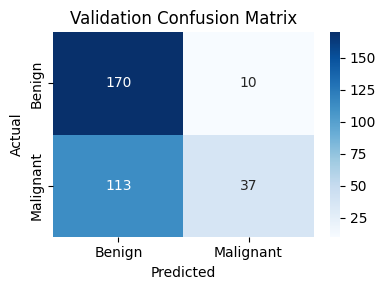


Test Metrics
Loss: 0.5908
Accuracy: 0.6576
Precision: 0.9111
Recall: 0.2733
F1: 0.4205


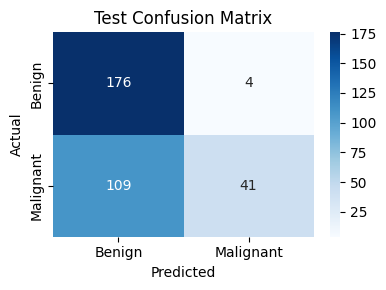

In [79]:
# Evaluate trained baseline on validation and test sets
criterion = nn.BCEWithLogitsLoss()

val_metrics = evaluate_model(trained_synthetic, val_loader, criterion, DEVICE)
test_metrics = evaluate_model(trained_synthetic, test_loader, criterion, DEVICE)

for split_name, metrics in [("Validation", val_metrics), ("Test", test_metrics)]:
    print(f"\n{split_name} Metrics")
    print(f"Loss: {metrics['val_loss']:.4f}")
    print(f"Accuracy: {metrics['accuracy']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall: {metrics['recall']:.4f}")
    print(f"F1: {metrics['f1']:.4f}")

    plt.figure(figsize=(4, 3))
    sns.heatmap(
        metrics['confusion_matrix'],
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Benign", "Malignant"],
        yticklabels=["Benign", "Malignant"]
    )
    plt.title(f"{split_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

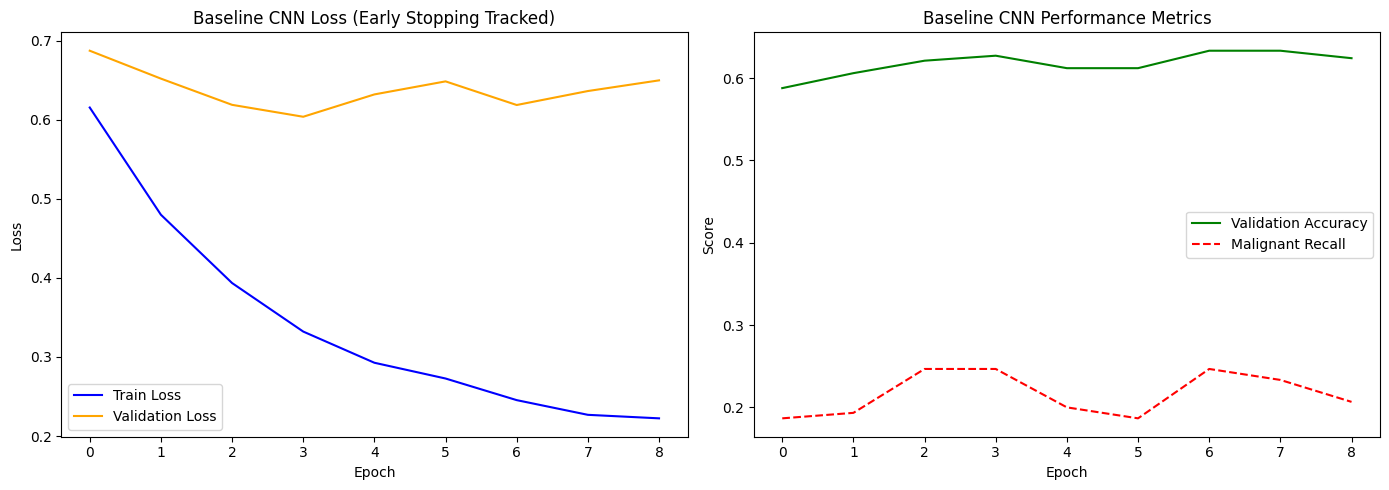

In [80]:
plot_training_history(synthetic_history, model_name="Baseline CNN")